In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Load Dataset

In [2]:
df = pd.read_csv("../data/processed_stock_data.csv")

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,MA20,MA50,MA100,MA200,Daily_Return,Volatility,RSI,MACD,MACD_Signal,BB_High,BB_Low
0,2015-10-16,24.883129,27.760000,28.0000,27.632500,27.945000,156930400,27.942375,28.08690,29.780450,30.332337,-0.007331,0.013303,47.247909,-0.155139,-0.182025,28.858909,27.025841
1,2015-10-19,25.037750,27.932501,27.9375,27.527500,27.700001,119036800,27.898875,28.06795,29.730325,30.335337,0.006214,0.012851,49.281038,-0.135251,-0.172670,28.726233,27.071517
2,2015-10-20,25.494900,28.442499,28.5425,27.705000,27.834999,195871200,27.903500,28.03820,29.689050,30.344737,0.018258,0.013110,54.824615,-0.077445,-0.153625,28.741855,27.065145
3,2015-10-21,25.492664,28.440001,28.8950,28.424999,28.500000,167180800,27.896500,28.03955,29.647100,30.354112,-0.000088,0.012978,54.793017,-0.031472,-0.129195,28.714228,27.078772
4,2015-10-22,25.882580,28.875000,28.8750,28.525000,28.582500,166616400,27.902750,28.04085,29.610950,30.363800,0.015295,0.013372,59.201625,0.039606,-0.095434,28.747926,27.057574


Select Close Price

In [3]:
data = df[["Close"]]

Scale Data

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

Create Sequences

In [5]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

Reshape

In [6]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)
print(y.shape)

(2507, 60, 1)
(2507,)


Train-Test Split

In [7]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Build LSTM Model

In [8]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

C:\Users\guruh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [9]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

Train Model

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0105 - val_loss: 0.0011
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0011 - val_loss: 9.7178e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.8550e-04 - val_loss: 0.0020
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 8.3624e-04 - val_loss: 0.0012
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 8.7022e-04 - val_loss: 9.3474e-04
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 8.8095e-04 - val_loss: 8.6889e-04
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.6569e-04 - val_loss: 0.0014
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.7362e-04 - val_loss: 8.3479e-04
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 8.5777e-04 - val_loss: 0.0019
Epoch 12/20
63/63 ━

Predict

In [11]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


Evaluate

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
r2 = r2_score(actual, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 13.288066058519824
RMSE: 14.953743602337193
R2  : 0.7303814012292915


Plot Results

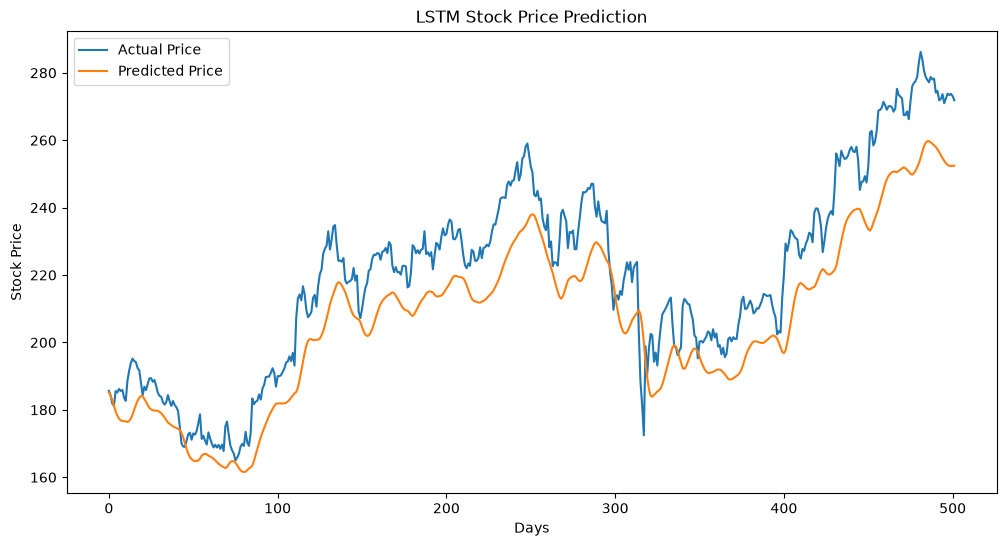

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("LSTM Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

Save LSTM Model

In [14]:
model.save("../models/lstm_stock_model.keras")

print("LSTM model saved successfully!")

LSTM model saved successfully!


Save Scaler


In [15]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [16]:
import os

print(os.listdir("../models"))

['feature_names.pkl', 'lstm_stock_model.keras', 'scaler.pkl', 'xgboost_stock_model.pkl']


GitHub Update